# RNR1 analysis
February 8, 2024


In [31]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
def deconvolve_gene(gene_name, replicate, save_dir):
    """
    Deconvolve a gene's gene expression and chromatin
    """
    from src.model import Model
    from cc_src.chromatin_model import ChromatinModel
    from src.config import load_yl_replicate1_rg1_alpha_vst_config, \
        load_yl_replicate2_rg1_alpha_vst_config
    
    if replicate == 1:
        config = load_yl_replicate1_rg1_alpha_vst_config()
    elif replicate == 2:
        config = load_yl_replicate2_rg1_alpha_vst_config()
    else:
        raise ValueError("Undefined replicate")
    
    print(f"Deconvolving {gene_name}, replicate={replicate}")
    print(f"Deconvolving gene expression...", end="")
    ge_model = Model(config, gene_name)
    ge_model.deconvolve_find_optimal_gamma()
    print("Done.")

    print(f"Deconvolving chromatin...", end="")
    chrom_model = ChromatinModel(config)
    chrom_model.load_mnase_gene(gene_name, replicate=config.replicate)
    chrom_model.gamma = 0.001
    chrom_model.deconvolve()
    print("Done.")
    
    save_name = f"{save_dir}/{gene_name}_rep{config.replicate}_chromatin.png"
    fig = chrom_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)
    plt.savefig(save_name, dpi=200)
    print(f"Saved figure to {save_name}")
    plt.close(fig)

    save_name = f"{save_dir}/{gene_name}_{config.replicate}_predicted.png"
    fig = chrom_model.plot_prediction_comparison()
    plt.savefig(save_name, dpi=200)
    print(f"Saved figure to {save_name}")
    plt.close(fig)


In [37]:
from cc_src.geneset import positive_control_genes

save_dir1 = "output/positive_controls_chromatin/rep1"
save_dir2 = "output/positive_controls_chromatin/rep2"

for replicate in [1, 2]:
    for gene_name in positive_control_genes()    
        deconvolve_gene(gene_name, replicate, save_dir1)
        print()


Deconvolving CLB2, replicate=1
Deconvolving gene expression...Done.
Deconvolving chromatin...Loading MNase reads for CLB2...Done.
The histogram shape around the TSS is: (3, 9)
The shape of the flattened grid to be deconvolved is: (16, 27)
Applying normalization using scaling matrix: output/mnase/rep1_len_scaling_3len_bins.csv
The shape of the flattened grid to be deconvolved is: (16, 27)
Deconvolved in : 00:00:09.75
The fitting norm is 0.91, the smoothing norm is: 50.71
Done.
Saved figure to output/positive_controls_chromatin/rep1/CLB2_rep1_chromatin.png
Saved figure to output/positive_controls_chromatin/rep1/CLB2_1_predicted.png


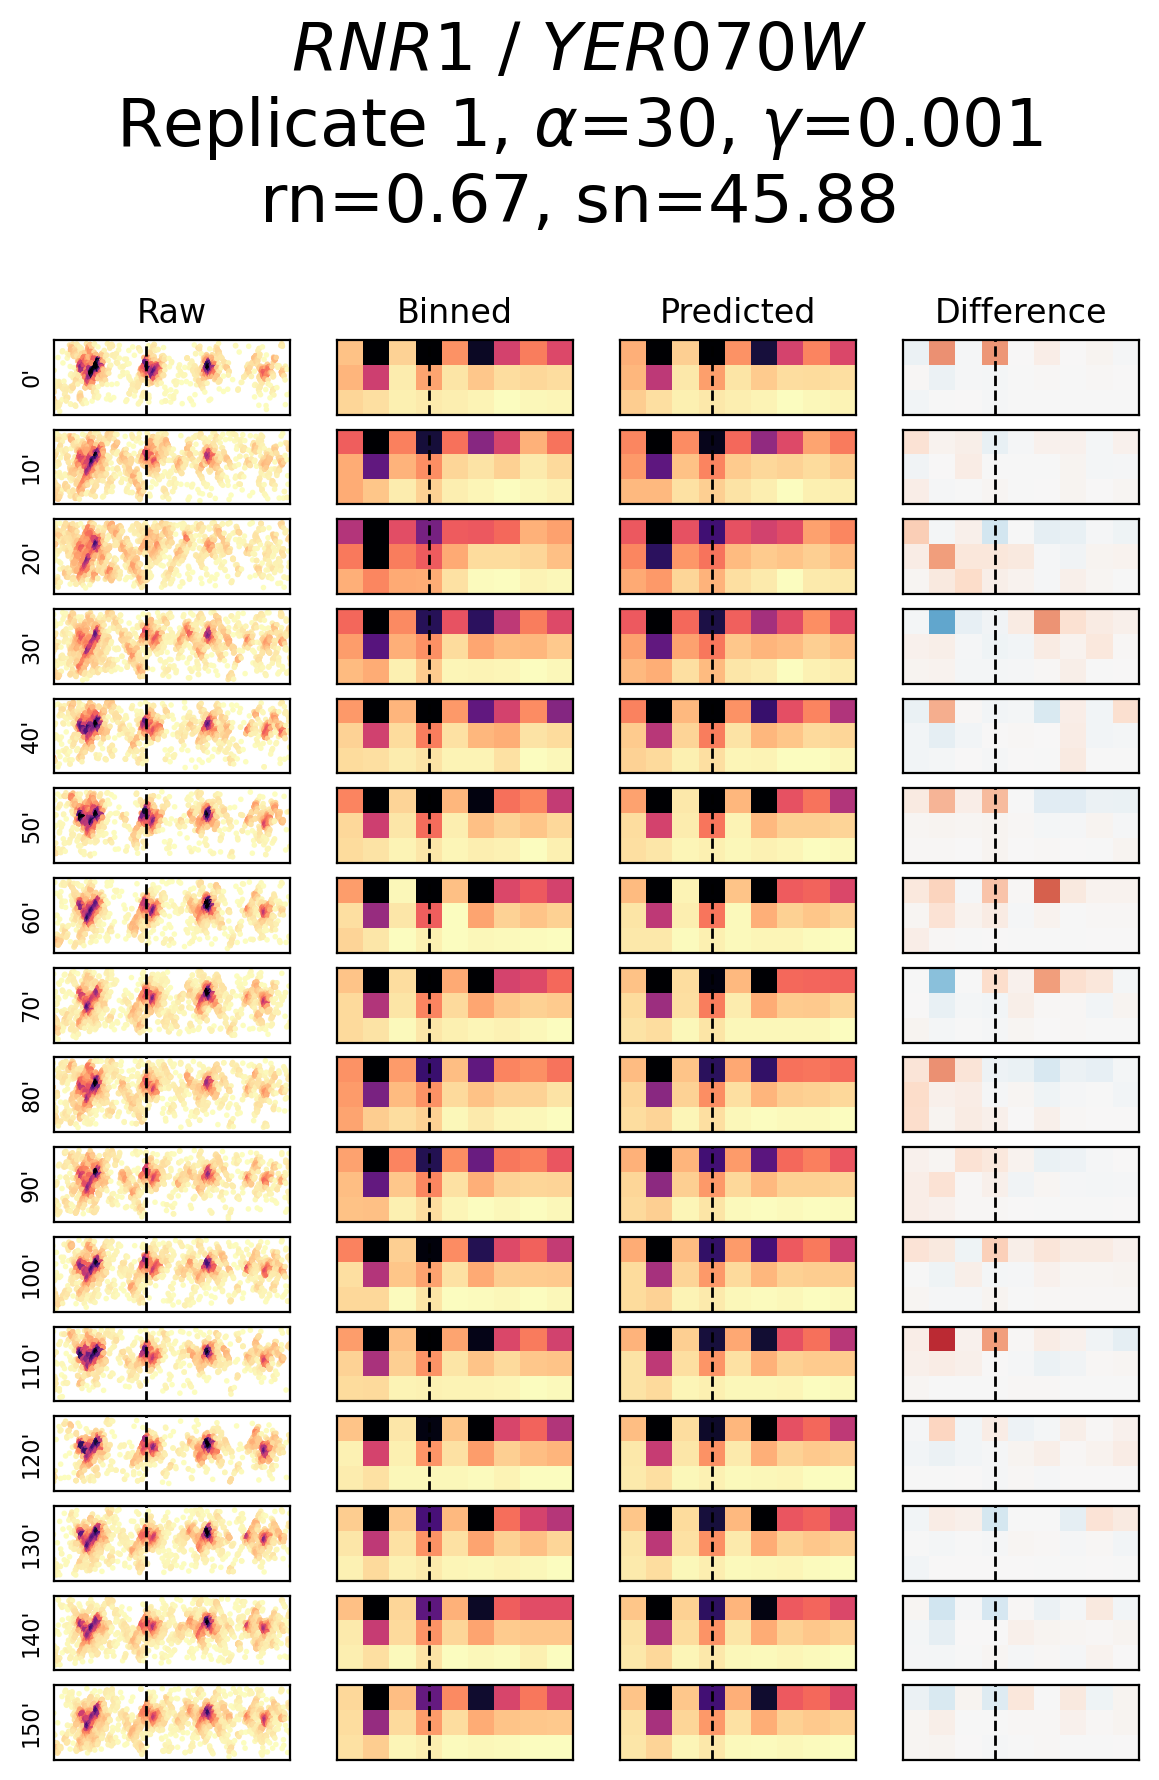

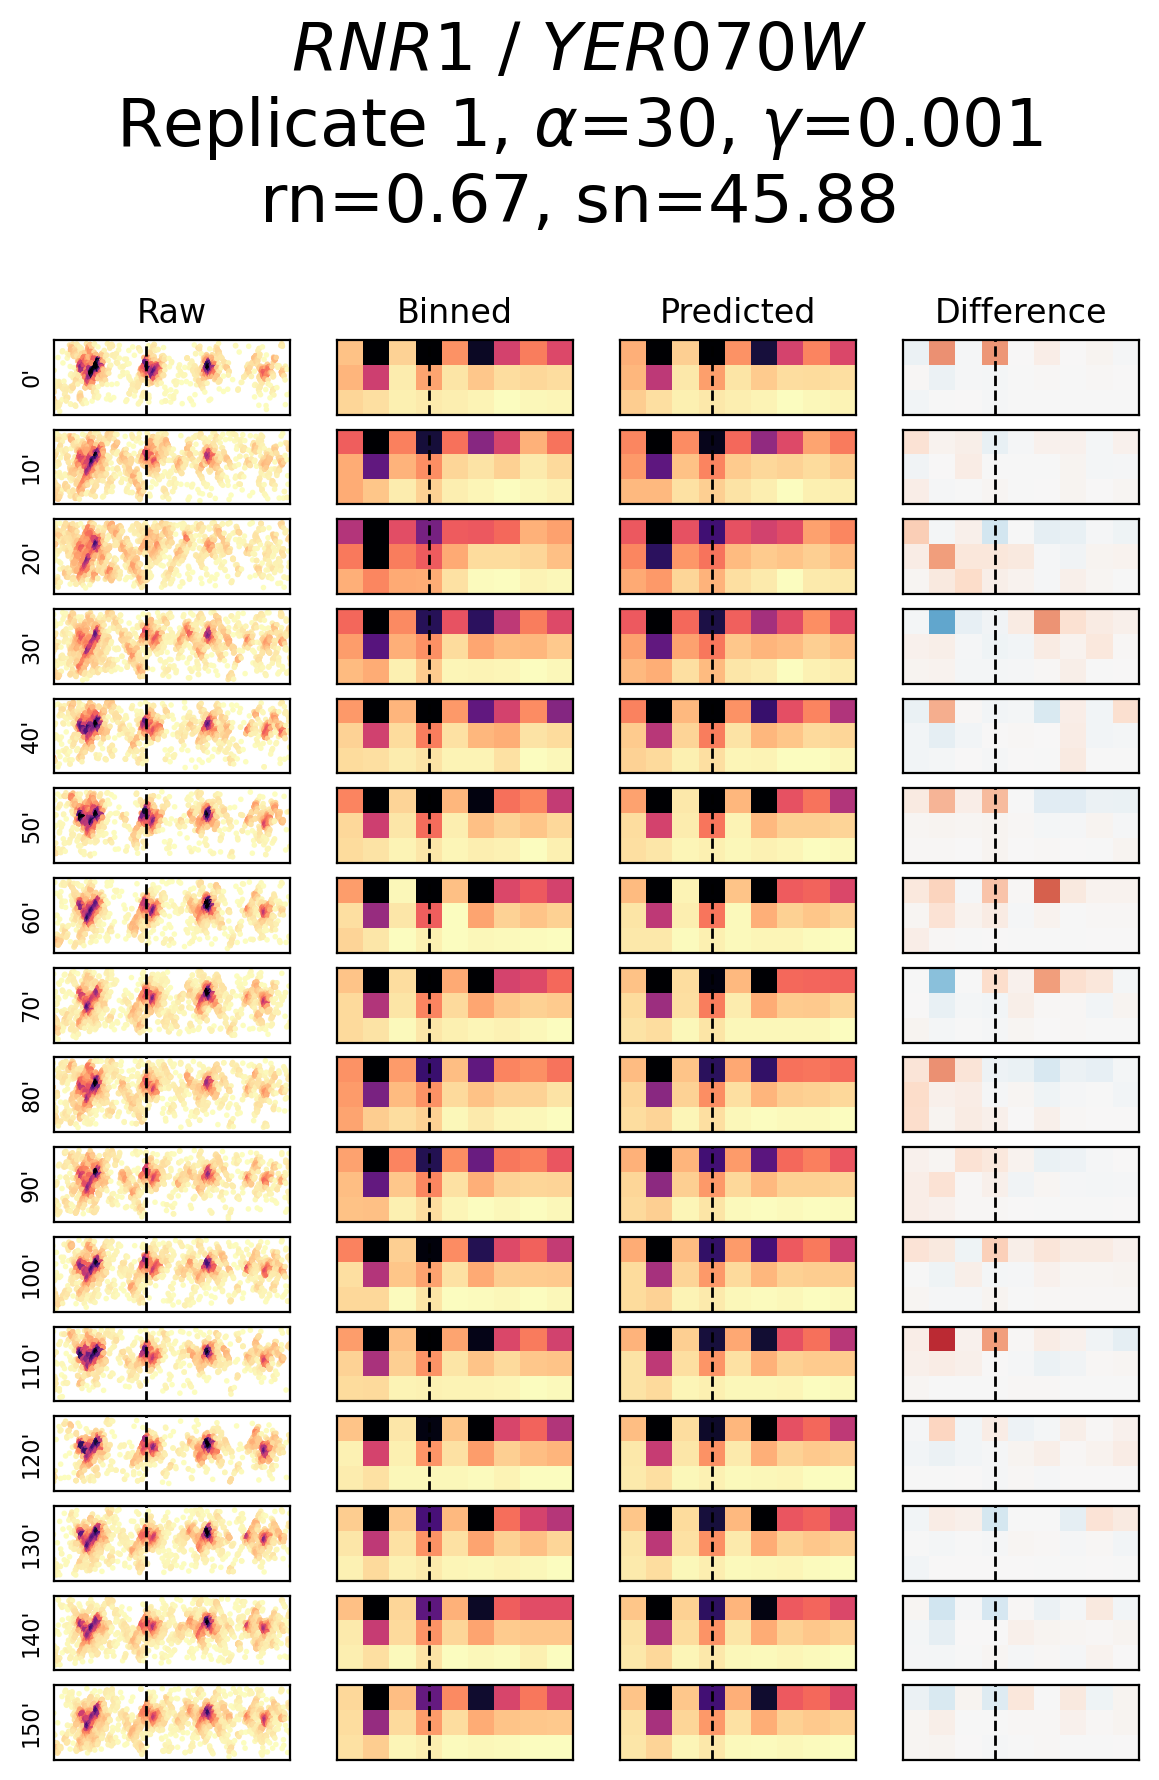